In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
kaggle = os.getenv("KAGGLE_API_TOKEN")

In [1]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('playground-series-s6e8')

print("Path to competition files:", path)

100%|██████████| 19.7M/19.7M [00:01<00:00, 18.9MB/s]

Extracting files...


Path to competition files: /Users/akashdeepsangwan/.cache/kagglehub/competitions/playground-series-s6e8


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn


In [3]:
train_data = pd.read_csv("train.csv")

In [4]:
train_data.head(10)

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1
5,5,28.0,7.37,1.78,1.56,3.38,8.33,210.0,40.0,7.85,Male,High,No,0
6,6,18.0,4.24,1.61,1.14,0.91,5.09,220.0,68.0,7.46,Other,Low,Yes,0
7,7,25.0,10.79,3.92,2.48,3.61,7.20,195.0,NaN,13.45,Other,High,No,1
8,8,26.0,8.42,2.57,3.41,1.90,6.64,99.0,27.0,8.35,Other,Medium,Yes,0
9,9,20.0,8.74,1.40,2.43,2.11,8.57,NaN,109.0,10.68,Other,High,NaN,1


In [5]:
train_data.shape

(691369, 14)

In [6]:
train_data.dtypes

id                           int64
age                        float64
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day      float64
app_opens_per_day          float64
weekend_screen_time        float64
gender                      object
stress_level                object
academic_work_impact        object
addicted_label               int64
dtype: object

In [7]:
X = train_data.copy()

In [8]:
X.drop(columns = ["id"], inplace = True)

In [9]:
y = train_data["addicted_label"].copy() 

In [10]:
X.drop(columns = ["addicted_label"], inplace = True)

In [11]:
# seperating the numerical and string columns
numerical_data = []
string_data = []

for col in X.columns :
    if X[col].dtype != object :
        numerical_data.append(col)
    else :
        string_data.append(col)

print("numerical-data \n", numerical_data)
print("string_data \n", string_data)

numerical-data 
 ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']
string_data 
 ['gender', 'stress_level', 'academic_work_impact']


### Implementing SimpleImputer

In [ ]:
from sklearn.impute import SimpleImputer

# median - less sensative to outlier than mean
num_imputer = SimpleImputer(strategy= "median")
cat_imputer = SimpleImputer(strategy="most_frequent")

X[numerical_data] = num_imputer.fit_transform(X[numerical_data])
X[string_data] = cat_imputer.fit_transform(X[string_data])


### First I need to do the label encoding as we  can't find the correlation until then
- In our case implementing the label encoding is not the best approach
- As it will lead to "Order" example : female = 0 , male =1 other =2  : according it might consider male > female


In [24]:
for col in string_data : 
    print(f"{col :} : \n {X[col].unique()}\n")

gender : 
 ['Male' 'Female' 'Other']

stress_level : 
 ['Medium' 'Low' 'High']

academic_work_impact : 
 ['No' 'Yes']



In [ ]:
X["academic_work_impact"] = X["academic_work_impact"].map({"No" : 0, "Yes" : 1})
X["stress_level"] = X["stress_level"].map({"Low" : 0, "Medium" : 1, "High" : 2})

In [27]:
X= pd.get_dummies(X, columns = ["gender"], dtype = int)

In [32]:
print(X.dtypes, "\n")# all numerical 
print(X.isnull().sum())


age                        float64
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day      float64
app_opens_per_day          float64
weekend_screen_time        float64
stress_level                 int64
academic_work_impact         int64
gender_Female                int64
gender_Male                  int64
gender_Other                 int64
dtype: object 

age                        0
daily_screen_time_hours    0
social_media_hours         0
gaming_hours               0
work_study_hours           0
sleep_hours                0
notifications_per_day      0
app_opens_per_day          0
weekend_screen_time        0
stress_level               0
academic_work_impact       0
gender_Female              0
gender_Male                0
gender_Other               0
dtype: int64


In [ ]:
train_data.columns

# we can create a function to check if the columns has strong correlation of 60% of features
# this condition can be implemented through a simple function
for col in train_data.columns :
    if train_data[col].dtype != object :
        print(f"{col} relation : \n {train_data.corr(numeric_only=True)[col]}\n")



id relation : 
 id                         1.000000
age                        0.001660
daily_screen_time_hours    0.003468
social_media_hours         0.004204
gaming_hours               0.002646
work_study_hours           0.002741
sleep_hours               -0.001409
notifications_per_day      0.001329
app_opens_per_day         -0.002363
weekend_screen_time        0.005208
Name: id, dtype: float64

age relation : 
 id                         0.001660
age                        1.000000
daily_screen_time_hours    0.013193
social_media_hours         0.011057
gaming_hours               0.004010
work_study_hours           0.001763
sleep_hours                0.000698
notifications_per_day     -0.007516
app_opens_per_day          0.002072
weekend_screen_time        0.018950
Name: age, dtype: float64

daily_screen_time_hours relation : 
 id                         0.003468
age                        0.013193
daily_screen_time_hours    1.000000
social_media_hours         0.597093
gaming_hours 

In [51]:
train_data.isnull().sum()

id                             0
age                        17138
daily_screen_time_hours    32788
social_media_hours         47397
gaming_hours               59420
work_study_hours           27777
sleep_hours                22455
notifications_per_day      34221
app_opens_per_day          25705
weekend_screen_time        50697
gender                     14212
stress_level               19626
academic_work_impact       25721
dtype: int64

In [ ]:
train_data.dtypes

id                           int64
age                        float64
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day      float64
app_opens_per_day          float64
weekend_screen_time        float64
gender                      object
stress_level                object
academic_work_impact        object
dtype: object

In [ ]:
train_data["gender"].drop_duplicates()

In [59]:
train_data["gender"].unique()

array(['Other', 'Female', 'Male', nan], dtype=object)

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
labelled = encoder.fit_transform(train_data[])

In [ ]:
max(train_data.isnull().sum())/len(train_data)*100
# How does it will effect if we remove the 20% of columns
# Data loss = Low Variance


20.053863963118708

In [46]:
len(train_data)

296302

In [ ]:
test_data=  pd.read_csv("test.csv")
test_data.head(10)

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
0,691369,30.0,9.34,NaN,0.77,4.09,7.15,153.0,16.0,NaN,Other,Medium,Yes
1,691370,NaN,NaN,1.91,NaN,1.20,8.67,239.0,148.0,10.68,Female,High,No
2,691371,26.0,8.48,3.64,NaN,3.39,7.47,106.0,123.0,NaN,Male,NaN,No
3,691372,20.0,8.37,2.99,1.69,2.53,5.45,178.0,55.0,9.88,Male,High,Yes
4,691373,25.0,8.25,4.02,1.21,2.32,8.46,63.0,86.0,10.72,Male,Low,No
5,691374,31.0,7.11,2.34,1.19,2.60,6.98,76.0,158.0,NaN,Other,Low,No
6,691375,19.0,8.96,0.99,0.45,1.59,8.88,142.0,78.0,10.03,Female,High,Yes
7,691376,26.0,5.19,NaN,1.20,0.96,8.73,224.0,98.0,6.17,Female,Low,No
8,691377,28.0,8.74,3.63,2.12,2.16,6.65,208.0,109.0,9.76,Other,Low,Yes
9,691378,34.0,NaN,NaN,1.67,NaN,7.87,154.0,41.0,NaN,Male,Medium,Yes


In [54]:
X.head(10)

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,gender_Female,gender_Male,gender_Other
0,24.0,7.77,1.83,1.59,2.11,7.46,122.0,38.0,8.63,1,0,0,1,0
1,19.0,5.97,1.08,1.33,3.03,8.22,76.0,19.0,9.58,1,0,1,0,0
2,18.0,5.09,2.31,1.33,2.20,6.25,134.0,60.0,7.47,0,1,1,0,0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,0,1,0,0,1
4,26.0,11.20,1.87,2.81,1.95,5.25,150.0,104.0,13.39,1,0,1,0,0
5,28.0,7.37,1.78,1.56,3.38,8.33,210.0,40.0,7.85,2,0,0,1,0
6,18.0,4.24,1.61,1.14,0.91,5.09,220.0,68.0,7.46,0,1,0,0,1
7,25.0,10.79,3.92,2.48,3.61,7.20,195.0,104.0,13.45,2,0,0,0,1
8,26.0,8.42,2.57,3.41,1.90,6.64,99.0,27.0,8.35,1,1,0,0,1
9,20.0,8.74,1.40,2.43,2.11,8.57,150.0,109.0,10.68,2,1,0,0,1


In [41]:
for col in X.columns:
    print(f"{col} : max : {X[col].max()}, min : {X[col].min()}")

age : max : 35.0, min : 18.0
daily_screen_time_hours : max : 15.0, min : 0.5
social_media_hours : max : 8.0, min : 0.0
gaming_hours : max : 4.0, min : 0.0
work_study_hours : max : 6.0, min : 0.0
sleep_hours : max : 9.0, min : 4.5
notifications_per_day : max : 250.0, min : 20.0
app_opens_per_day : max : 180.0, min : 15.0
weekend_screen_time : max : 17.56, min : 0.51
stress_level : max : 2, min : 0
academic_work_impact : max : 1, min : 0
gender_Female : max : 1, min : 0
gender_Male : max : 1, min : 0
gender_Other : max : 1, min : 0


In [55]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(type(X_scaled))

<class 'numpy.ndarray'>


In [57]:
X_scaled = pd.DataFrame(X_scaled, columns = X.columns, index = X.index)
X_scaled.describe().loc[["mean", "std"]]

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,gender_Female,gender_Male,gender_Other
mean,-1.639440e-16,-1.692060e-16,2.681972e-16,-2.269234e-17,5.903298e-17,-2.538912e-16,1.022800e-16,-6.684375e-17,2.029156e-16,-7.251684e-17,6.186953e-17,5.331879e-17,2.137685e-17,-7.317459e-17
std,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00


In [59]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)


In [61]:
print("per-component variance : \n", explained , "/n", len(explained))
print("\n Cumulative variance : \n", cumulative)


per-component variance : 
 [1.76687471e-01 1.09687263e-01 1.04741810e-01 7.46420794e-02
 7.39092875e-02 7.12309939e-02 7.06882172e-02 7.02275138e-02
 6.90567676e-02 6.74849720e-02 6.37292497e-02 3.12041176e-02
 1.67102574e-02 6.52427485e-15] /n 14

 Cumulative variance : 
 [0.17668747 0.28637473 0.39111654 0.46575862 0.53966791 0.6108989
 0.68158712 0.75181464 0.8208714  0.88835638 0.95208562 0.98328974
 1.         1.        ]


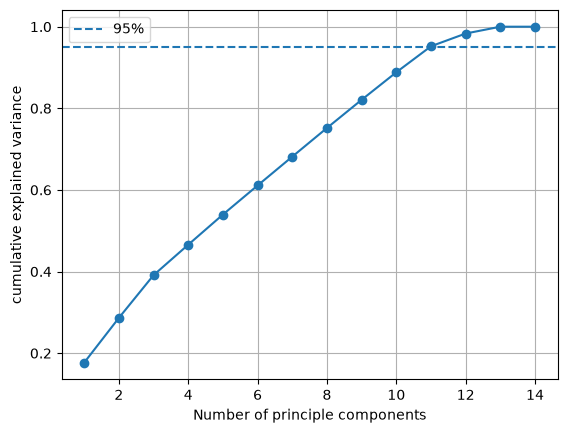

In [62]:
plt.plot(range(1, len(explained)+1), cumulative, marker ="o")
plt.axhline(0.95, linestyle = "--", label = "95%")
plt.xlabel("Number of principle components")
plt.ylabel("cumulative explained variance")
plt.legend()
plt.grid(True)
plt.show()

In [64]:
X.columns

Index(['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
       'work_study_hours', 'sleep_hours', 'notifications_per_day',
       'app_opens_per_day', 'weekend_screen_time', 'stress_level',
       'academic_work_impact', 'gender_Female', 'gender_Male', 'gender_Other'],
      dtype='object')

- Check can you remove all the 3 columns from the dataset and keep 11 columns
- or you need to add one more column as make them as 12 
daily_screen_time_hours, social_media_hours, weekend_screen_time